# CSCI E-89 — Homework 3, Problem 2
## Fashion-MNIST Image Classifier with PyTorch

**Author:** Daniella Olivas

This notebook builds, trains and evaluates a multilayer perceptron (MLP) that classifies
Fashion-MNIST images into 10 clothing categories. It covers:

1. Loading and preprocessing the Fashion-MNIST dataset
2. Building the neural network architecture
3. Training the classifier using SGD and CrossEntropyLoss
4. Plotting training and validation accuracy across epochs
5. Evaluating the trained model and generating predictions

All cells are self-contained and should be run in order from top to bottom.

## 0. Setup

### 0.1 Imports

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.ticker import MaxNLocator, PercentFormatter
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version:     {torch.__version__}")

PyTorch version:     2.14.0+cu130


### 0.2 Configuration and reproducibility

A random seed of 42 is set for Python, NumPy and PyTorch so the data split, weight
initialization and training shuffle are the same on every run.

In [2]:
SEED = 42
BATCH_SIZE = 32
DATA_DIR = "./data"
TRAIN_SIZE = 55_000
VAL_SIZE = 5_000

LEARNING_RATE = 0.1
NUM_EPOCHS = 5

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


def set_seed(seed: int = SEED) -> None:
    """Seed Python, NumPy and PyTorch for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

### 0.3 Device selection

Use the GPU if one is available, otherwise fall back to the CPU.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Loading and Preprocessing the Fashion-MNIST Dataset

### 1.1 Download the dataset and convert images to tensors

`transforms.ToTensor()` converts each 28×28 grayscale image (integers 0–255) into a
`float32` tensor of shape `(1, 28, 28)` with pixel values scaled to the range [0, 1].

In [4]:
transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

print(f"Original training images: {len(full_train_dataset):,}")
print(f"Test images:              {len(test_dataset):,}")

Original training images: 60,000
Test images:              10,000


### 1.2 Split into training and validation sets

The original 60,000 training images are split into **55,000 training** and
**5,000 validation** images. The **10,000 test images** are kept separate.

In [5]:
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED),
)

print(f"Training images:   {len(train_dataset):,}")
print(f"Validation images: {len(val_dataset):,}")
print(f"Test images:       {len(test_dataset):,}")

Training images:   55,000
Validation images: 5,000
Test images:       10,000


### 1.3 Create the DataLoaders

Batches of 32 images. Only the training data is shuffled.

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 1.4 Inspect a batch

Confirm the tensor shapes, data type and pixel value range. A validation batch is used
so the training loader's shuffle order is left untouched for training.

In [7]:
images, labels = next(iter(val_loader))
print(f"Batch images shape: {tuple(images.shape)}, dtype: {images.dtype}")
print(f"Batch labels shape: {tuple(labels.shape)}, dtype: {labels.dtype}")
print(f"Pixel value range:  [{images.min().item():.1f}, {images.max().item():.1f}]")

Batch images shape: (32, 1, 28, 28), dtype: torch.float32
Batch labels shape: (32,), dtype: torch.int64
Pixel value range:  [0.0, 1.0]


## 2. Building the Neural Network Architecture

The model is a multilayer perceptron defined with `nn.Module`:

| Layer | Output size | Activation |
|---|---|---|
| Flatten (28 × 28) | 784 | — |
| Hidden layer 1 | 300 | ReLU |
| Hidden layer 2 | 100 | ReLU |
| Output layer | 10 | — (logits) |

The output layer returns raw logits (no Softmax), which is what `nn.CrossEntropyLoss` expects.

In [8]:
class FashionMNISTClassifier(nn.Module):
    def __init__(self, input_size=28 * 28, hidden1_size=300,
                 hidden2_size=100, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(input_size, hidden1_size)
        self.hidden2 = nn.Linear(hidden1_size, hidden2_size)
        self.output = nn.Linear(hidden2_size, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)                # (batch, 1, 28, 28) -> (batch, 784)
        x = self.relu(self.hidden1(x))     # (batch, 300)
        x = self.relu(self.hidden2(x))     # (batch, 100)
        return self.output(x)              # (batch, 10) logits

### 2.1 Create the model and move it to the device

In [9]:
set_seed(SEED)  # makes the weight initialization reproducible
model = FashionMNISTClassifier().to(device)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {num_params:,}")

FashionMNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=300, bias=True)
  (hidden2): Linear(in_features=300, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
)

Trainable parameters: 266,610


### 2.2 Sanity check: forward pass on one batch

In [10]:
with torch.no_grad():
    logits = model(images.to(device))
print(f"Input batch shape:   {tuple(images.shape)}")
print(f"Output logits shape: {tuple(logits.shape)}")

Input batch shape:   (32, 1, 28, 28)
Output logits shape: (32, 10)


## 3. Training the Classifier Using SGD and CrossEntropyLoss

### 3.1 Loss function and optimizer

- **Loss:** `nn.CrossEntropyLoss` (applies Softmax internally to the logits)
- **Optimizer:** Stochastic Gradient Descent with a learning rate of 0.1

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

### 3.2 Training and evaluation functions

- `train_one_epoch` updates the weights on the training set.
- `evaluate` measures loss and accuracy with the weights frozen (`model.eval()` and `torch.no_grad()`).

Both return the average loss per image and the fraction of images classified correctly.

In [12]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    """Train for one epoch; return (average loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, loss_fn, device):
    """Evaluate without updating weights; return (average loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

### 3.3 Train for 5 epochs

Training loss, training accuracy, validation loss and validation accuracy are recorded
after every epoch.

In [13]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}"
    )

Epoch 1/5 | train loss: 0.6045, train acc: 0.7783 | val loss: 0.4279, val acc: 0.8412


Epoch 2/5 | train loss: 0.4080, train acc: 0.8493 | val loss: 0.4050, val acc: 0.8496


Epoch 3/5 | train loss: 0.3626, train acc: 0.8639 | val loss: 0.4043, val acc: 0.8546


Epoch 4/5 | train loss: 0.3355, train acc: 0.8747 | val loss: 0.3647, val acc: 0.8676


Epoch 5/5 | train loss: 0.3149, train acc: 0.8819 | val loss: 0.3446, val acc: 0.8720


## 4. Plotting Training and Validation Accuracy Across Epochs

Both curves are drawn on the same graph for comparison. The lines use different markers
as well as colors so they can be told apart without relying on color alone.

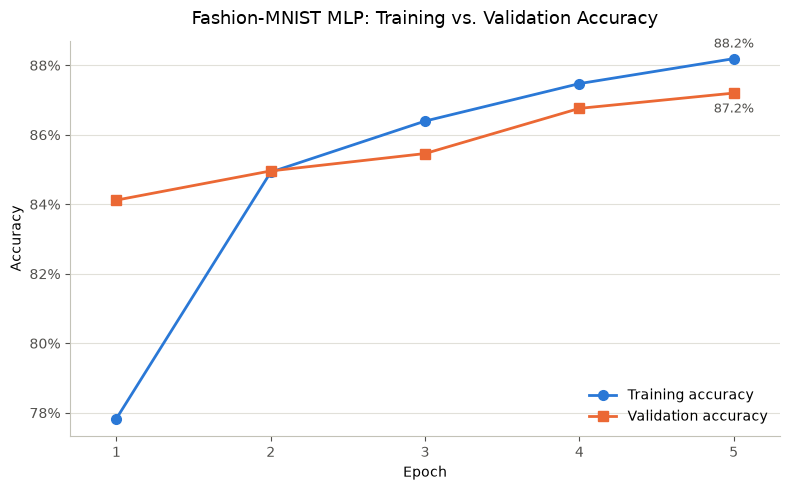

In [14]:
TRAIN_COLOR, VAL_COLOR = "#2a78d6", "#eb6834"
TEXT_COLOR, GRID_COLOR, AXIS_COLOR = "#52514e", "#e1e0d9", "#c3c2b7"

train_acc_pct = [acc * 100 for acc in history["train_acc"]]
val_acc_pct = [acc * 100 for acc in history["val_acc"]]
epochs = range(1, len(train_acc_pct) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_acc_pct, color=TRAIN_COLOR, linewidth=2,
        marker="o", markersize=7, label="Training accuracy")
ax.plot(epochs, val_acc_pct, color=VAL_COLOR, linewidth=2,
        marker="s", markersize=7, label="Validation accuracy")

# Label the final value of each line.
for values, other in ((train_acc_pct, val_acc_pct), (val_acc_pct, train_acc_pct)):
    offset = 8 if values[-1] >= other[-1] else -14
    ax.annotate(f"{values[-1]:.1f}%", xy=(epochs[-1], values[-1]),
                xytext=(0, offset), textcoords="offset points",
                ha="center", fontsize=9, color=TEXT_COLOR)

ax.set_title("Fashion-MNIST MLP: Training vs. Validation Accuracy", fontsize=13, pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlim(0.7, len(train_acc_pct) + 0.3)

ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS_COLOR)
ax.tick_params(colors=TEXT_COLOR)
ax.legend(loc="lower right", frameon=False)

fig.tight_layout()
plt.show()

## 5. Evaluating the Trained Model and Generating Predictions

### 5.1 Switch to evaluation mode

`model.eval()` puts the model in evaluation mode, and `torch.no_grad()` (used below)
disables gradient calculations since no weights are updated.

In [15]:
model.eval()

FashionMNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=300, bias=True)
  (hidden2): Linear(in_features=300, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
)

### 5.2 Predict three validation images

The model's output logits are converted into probabilities with **Softmax**, and the
**four most probable clothing categories** are shown for each image. Results are moved
back to the CPU before being converted to Python values.

In [16]:
NUM_SAMPLES = 3
TOP_K = 4

sample_images = torch.stack([val_dataset[i][0] for i in range(NUM_SAMPLES)])
sample_labels = torch.tensor([val_dataset[i][1] for i in range(NUM_SAMPLES)])

with torch.no_grad():
    sample_logits = model(sample_images.to(device))
    sample_probs = F.softmax(sample_logits, dim=1).cpu()

top_probs, top_classes = sample_probs.topk(TOP_K, dim=1)
predicted_labels = top_classes[:, 0]

for i in range(NUM_SAMPLES):
    print(f"Validation image {i + 1}")
    print(f"  Top {TOP_K} most probable categories:")
    for rank, (prob, cls) in enumerate(zip(top_probs[i], top_classes[i]), 1):
        print(f"    {rank}. {CLASS_NAMES[cls]:<12} {prob.item():7.2%}")
    print()

Validation image 1
  Top 4 most probable categories:
    1. Sneaker       93.14%
    2. Ankle boot     4.61%
    3. Sandal         2.03%
    4. Bag            0.13%

Validation image 2
  Top 4 most probable categories:
    1. Coat          93.75%
    2. Pullover       6.05%
    3. Shirt          0.20%
    4. Bag            0.00%

Validation image 3
  Top 4 most probable categories:
    1. Pullover      90.10%
    2. Coat           5.61%
    3. Shirt          3.47%
    4. T-shirt/top    0.45%



### 5.3 Compare predicted labels with actual labels

Image 1: actual = Sneaker      predicted = Sneaker      (CORRECT)
Image 2: actual = Coat         predicted = Coat         (CORRECT)
Image 3: actual = Pullover     predicted = Pullover     (CORRECT)


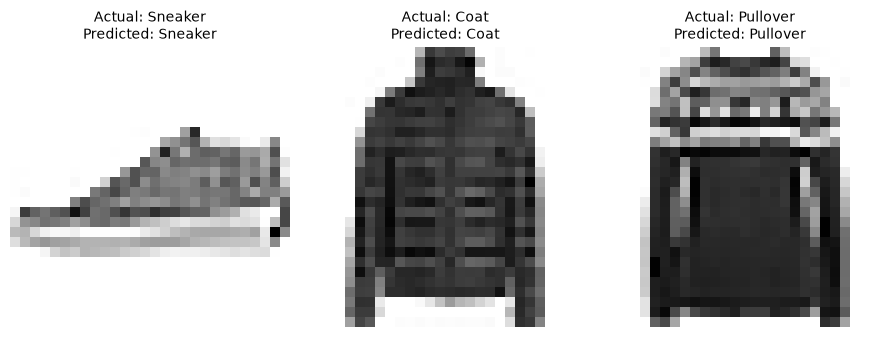


Sample predictions correct: 3/3


In [17]:
fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(9, 3.4))
for i, ax in enumerate(axes):
    actual = CLASS_NAMES[sample_labels[i]]
    predicted = CLASS_NAMES[predicted_labels[i]]
    result = "CORRECT" if predicted_labels[i] == sample_labels[i] else "WRONG"
    print(f"Image {i + 1}: actual = {actual:<12} predicted = {predicted:<12} ({result})")

    ax.imshow(sample_images[i].squeeze(), cmap="gray_r")
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}", fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

num_correct = (predicted_labels == sample_labels).sum().item()
print(f"\nSample predictions correct: {num_correct}/{NUM_SAMPLES}")

### 5.4 Overall classification accuracy on the test dataset

In [18]:
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test accuracy: {test_accuracy:.2%} on {total:,} test images")

Test accuracy: 87.13% on 10,000 test images


## 6. Conclusion

The two-hidden-layer MLP (784 → 300 → 100 → 10, 266,610 parameters) was trained for
5 epochs with SGD (learning rate 0.1) and CrossEntropyLoss.

- **The model generalizes well.** Test accuracy is almost the same as the final
  validation accuracy, so the validation set gave a reliable estimate of performance
  on new images.
- **There is no sign of overfitting yet.** Training and validation accuracy differ by
  only about 1 percentage point, and both losses were still decreasing at epoch 5.
- **The mistakes are sensible.** When the model is unsure, the runner-up category is a
  visually similar item (e.g. sneaker vs. ankle boot, coat vs. pullover).

**Limitations and possible improvements:**
- Flattening the image discards its 2-D structure; a convolutional neural network (CNN)
  typically exceeds 90% accuracy on Fashion-MNIST.
- Training was short; more epochs, a learning-rate schedule or an optimizer such as Adam
  would likely raise accuracy.
- With longer training, dropout or early stopping would help prevent overfitting.